In [ ]:
import os
from typing import TypedDict, Optional

from dotenv import load_dotenv
load_dotenv()

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage  # adjust import path if needed
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Command                  #newline
from langgraph.checkpoint.memory import InMemorySaver


# 1. LLM setup
def get_groq_llm() -> ChatOpenAI:
    return ChatOpenAI(
        model="gpt-4o-mini",
        api_key=os.getenv("OPENAI_API_KEY"),
        temperature=0.4,
        max_tokens=2000
    )

llm = get_groq_llm()

In [6]:
# 2. Define State schema
class PostState(TypedDict, total=False):
    info: dict                  # input information for the post (topic, tone, audience, key points)
    draft: str                  # current draft of LinkedIn post
    human_feedback: Optional[str]  # feedback from human reviewer
    approved: bool              # whether human reviewer approved
    final_post: Optional[str]    # final approved post content

In [7]:
# 3. Node: Generate initial draft
def generate_draft(state: PostState) -> dict:
    info = state["info"]

    # Build prompt based on info
    prompt = f"""You are writing a LinkedIn post. Here is the info:
Topic: {info.get('topic')}
Key points: {info.get('key_points')}
Tone: {info.get('tone')}
Audience: {info.get('audience')}

Write a LinkedIn-style post (1-2 short paragraphs) with that info."""

    response = llm.invoke([HumanMessage(content=prompt)])
    draft = response.content.strip()

    print("=== AI Generated Draft ===")
    print(draft)

    return {"draft": draft, "approved": False}


In [ ]:
# 4. Node: Ask human reviewer for feedback/approval
def ask_for_feedback(state: PostState) -> dict:
    print("\n=== PAUSING FOR HUMAN REVIEW ===")
    print("Draft to review:")
    print(state["draft"])

    # Use interrupt to pause and wait for human input
    feedback = interrupt("Please review the draft. Provide feedback (or type 'approve' to approve): ")

    # Determine approval based on exact word (you may define logic)
    approved = feedback.strip().lower() == "approved"
    return {"human_feedback": feedback, "approved": approved }


In [11]:
# 5. Node: Decide next step
# def decide_next_step(state: PostState) -> Command:
#     if state.get("approved"):
#         return Command(goto="post_to_linkedIn")
#     else:
#         return Command(goto="revise_draft")

def decide_next(state: PostState) -> str:
    if state.get("approved", False):
        return "approved"
    else:
        return "revise"

In [12]:
# 6. Node: Revise draft based on feedback
def revise_draft(state: PostState) -> dict:
    feedback = state["human_feedback"]
    old_draft = state["draft"]

    prompt = f"""You are rewriting a LinkedIn post. Original draft:
{old_draft}

Feedback from reviewer:
{feedback}

Revise the draft accordingly (keeping same tone and audience) and output the improved post."""

    response = llm.invoke([HumanMessage(content=prompt)])
    new_draft = response.content.strip()

    print("=== AI Revised Draft ===")
    print(new_draft)

    return {"draft": new_draft, "approved": False}

In [ ]:
# 7. Node: Post to LinkedIn (stub)
def post_to_linkedin(state: PostState) -> dict:
    final = state["draft"]

    # Here you would make the real LinkedIn API call.
    # e.g. linkedin_client.post_update(final)

    print("=== POSTING TO LINKEDIN ===")
    print(final)

    # After posting, you can set final_post
    return {"final_post": final}

   

In [14]:
# 8. Build the workflow graph
def build_workflow_graph() -> StateGraph:
    builder = StateGraph(PostState)

    builder.add_node("generate_draft", generate_draft)
    builder.add_node("ask_for_feedback", ask_for_feedback)
    builder.add_node("revise_draft", revise_draft)
    builder.add_node("post_to_linkedin", post_to_linkedin)

    # Define edges
    builder.add_edge(START, "generate_draft")

    # builder.add_edge("generate_draft", "ask_for_feedback")
    # builder.add_conditional_edges("ask_for_feedback", decide_next, {"approved": "post_to_linkedin", "needs_improvement": "revise_draft"})
    # builder.add_edge("revise_draft", "ask_for_feedback")
    # builder.add_edge("post_to_linkedin", END)

    builder.add_edge("generate_draft", "ask_for_feedback")
    builder.add_conditional_edges(
        "ask_for_feedback",
        decide_next,
        {
            "approved": "post_to_linkedin",
            "revise": "revise_draft"
        }
    )

    builder.add_edge("revise_draft", "ask_for_feedback")
    builder.add_edge("post_to_linkedin", END)

    # Compile with checkpointing to support interrupt/resume
    graph = builder.compile(checkpointer=InMemorySaver())

    return graph
graph = build_workflow_graph()

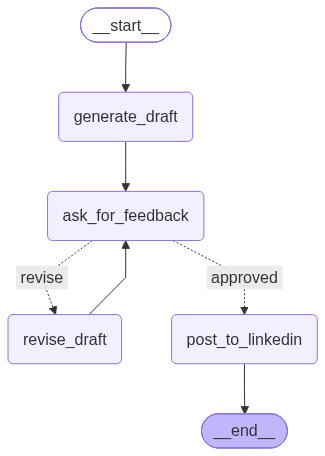

In [15]:
graph

In [ ]:
# 9. Usage / Execution
if __name__ == "__main__":
    # Example input info
    input_info = {
        "topic": "Data Science Workflow Automation with LangGraph",
        "key_points": "human-in-the-loop, agentic workflow, LinkedIn posts, brand voice",
        "tone": "professional yet friendly",
        "audience": "data scientists and AI practitioners on LinkedIn"
    }

    initial_state: PostState = {
        "info": input_info,
        "draft": "",
        "human_feedback": None,
        "approved": False,
        "final_post": None
    }

    graph = build_workflow_graph()
    thread_id = "linkedin_post_thread_1"
    config = { "configurable":{"thread_id":thread_id}}

    # Start workflow
    result = graph.invoke(initial_state, config=config)

    # When it hits interrupt (in ask_for_feedback), you'll need to resume manually:
    # For example:
    # graph.invoke(Command(resume="Looks great, approve"), config=config)

    # In a real UI setup you'd capture human input & call resume programmatically.

    print("\nWorkflow ended. Final state:")
    print(graph.get_state(config))

=== AI Generated Draft ===
🚀 Excited to share insights on Data Science Workflow Automation with LangGraph! As data scientists and AI practitioners, we know that efficiency is key to unlocking the full potential of our projects. By integrating a human-in-the-loop approach, LangGraph empowers us to create an agentic workflow that not only enhances productivity but also maintains the quality and integrity of our results. 

Imagine crafting LinkedIn posts that resonate with your brand voice while automating the tedious aspects of data processing. With LangGraph, you can focus on what truly matters—driving innovation and insights. Let’s embrace this transformative journey together! 💡 #DataScience #AI #WorkflowAutomation #LangGraph

=== PAUSING FOR HUMAN REVIEW ===
Draft to review:
🚀 Excited to share insights on Data Science Workflow Automation with LangGraph! As data scientists and AI practitioners, we know that efficiency is key to unlocking the full potential of our projects. By integrati

In [23]:
print( graph.get_state(config))

StateSnapshot(values={'info': {'topic': 'Data Science Workflow Automation with LangGraph', 'key_points': 'human-in-the-loop, agentic workflow, LinkedIn posts, brand voice', 'tone': 'professional yet friendly', 'audience': 'data scientists and AI practitioners on LinkedIn'}, 'draft': '🚀 Excited to share insights on Data Science Workflow Automation with LangGraph! As data scientists and AI practitioners, we know that efficiency is key to unlocking the full potential of our projects. By integrating a human-in-the-loop approach, LangGraph empowers us to create an agentic workflow that not only enhances productivity but also maintains the quality and integrity of our results. \n\nImagine crafting LinkedIn posts that resonate with your brand voice while automating the tedious aspects of data processing. With LangGraph, you can focus on what truly matters—driving innovation and insights. Let’s embrace this transformative journey together! 💡 #DataScience #AI #WorkflowAutomation #LangGraph', 'h

### Mannual resume
input() will open the popup to take input from user at VC searchbar and user can put "approved" or "revise"

In [24]:
# Step 2: Pause at human review
state = graph.get_state(config)
interrupts = getattr(state, "interrupts", None) or []

if not interrupts:
    print("⚠️ Unexpected: no interrupt was raised for human review.")
else:
    for intr in interrupts:
        print(f"Interrupt ID: {intr.id}, prompt: {intr.value}")

    # Ask human for feedback . 
    human_answer = input("Enter feedback or type 'approve': ")

    # Step 3: Resume workflow with human feedback
    result2 = graph.invoke(
        Command(resume={interrupts[0].id: human_answer}),
        config=config
    )
    print("===After resume with human feedback ====")
    print(graph.get_state(config))


Interrupt ID: 3f0444455b470e2cfdec2685cbaf9289, prompt: Please review the draft. Provide feedback (or type 'approve' to approve): 

=== PAUSING FOR HUMAN REVIEW ===
Draft to review:
🚀 Excited to share insights on Data Science Workflow Automation with LangGraph! As data scientists and AI practitioners, we know that efficiency is key to unlocking the full potential of our projects. By integrating a human-in-the-loop approach, LangGraph empowers us to create an agentic workflow that not only enhances productivity but also maintains the quality and integrity of our results. 

Imagine crafting LinkedIn posts that resonate with your brand voice while automating the tedious aspects of data processing. With LangGraph, you can focus on what truly matters—driving innovation and insights. Let’s embrace this transformative journey together! 💡 #DataScience #AI #WorkflowAutomation #LangGraph
=== POSTING TO LINKEDIN ===
🚀 Excited to share insights on Data Science Workflow Automation with LangGraph! A

In [25]:
# Step 4: Check if approved. If not, ask human for next step or loop.
final_state = graph.get_state(config)

print("\n--- Final State Check ---")
print(final_state)


--- Final State Check ---
StateSnapshot(values={'info': {'topic': 'Data Science Workflow Automation with LangGraph', 'key_points': 'human-in-the-loop, agentic workflow, LinkedIn posts, brand voice', 'tone': 'professional yet friendly', 'audience': 'data scientists and AI practitioners on LinkedIn'}, 'draft': '🚀 Excited to share insights on Data Science Workflow Automation with LangGraph! As data scientists and AI practitioners, we know that efficiency is key to unlocking the full potential of our projects. By integrating a human-in-the-loop approach, LangGraph empowers us to create an agentic workflow that not only enhances productivity but also maintains the quality and integrity of our results. \n\nImagine crafting LinkedIn posts that resonate with your brand voice while automating the tedious aspects of data processing. With LangGraph, you can focus on what truly matters—driving innovation and insights. Let’s embrace this transformative journey together! 💡 #DataScience #AI #Workflo

In [27]:
# Feedback you got from human
feedback_value = "approved"

# Use the interrupt ID from the snapshot: e.g. "52d70f009780e04a698659d87dddb6d0"
resume_command = Command(
    resume={"1f1ac520-efab-6ddd-8003-c8739639bf60": feedback_value}
)

# Invoke the graph to resume
result = graph.invoke(resume_command, config=config)

# Then check the updated state
state_after = graph.get_state(config)

print("State after resuming:", state_after)

State after resuming: StateSnapshot(values={'info': {'topic': 'Data Science Workflow Automation with LangGraph', 'key_points': 'human-in-the-loop, agentic workflow, LinkedIn posts, brand voice', 'tone': 'professional yet friendly', 'audience': 'data scientists and AI practitioners on LinkedIn'}, 'draft': '🚀 Excited to share insights on Data Science Workflow Automation with LangGraph! As data scientists and AI practitioners, we know that efficiency is key to unlocking the full potential of our projects. By integrating a human-in-the-loop approach, LangGraph empowers us to create an agentic workflow that not only enhances productivity but also maintains the quality and integrity of our results. \n\nImagine crafting LinkedIn posts that resonate with your brand voice while automating the tedious aspects of data processing. With LangGraph, you can focus on what truly matters—driving innovation and insights. Let’s embrace this transformative journey together! 💡 #DataScience #AI #WorkflowAuto

In [29]:
list(graph.get_state_history(config=config))

[StateSnapshot(values={'info': {'topic': 'Data Science Workflow Automation with LangGraph', 'key_points': 'human-in-the-loop, agentic workflow, LinkedIn posts, brand voice', 'tone': 'professional yet friendly', 'audience': 'data scientists and AI practitioners on LinkedIn'}, 'draft': '🚀 Excited to share insights on Data Science Workflow Automation with LangGraph! As data scientists and AI practitioners, we know that efficiency is key to unlocking the full potential of our projects. By integrating a human-in-the-loop approach, LangGraph empowers us to create an agentic workflow that not only enhances productivity but also maintains the quality and integrity of our results. \n\nImagine crafting LinkedIn posts that resonate with your brand voice while automating the tedious aspects of data processing. With LangGraph, you can focus on what truly matters—driving innovation and insights. Let’s embrace this transformative journey together! 💡 #DataScience #AI #WorkflowAutomation #LangGraph', '

### Automatic Loop Resume

In [ ]:
# 9. Automatic loop execution
if __name__ == "__main__":
    # Example input info
    input_info = {
        "topic": "Data Science Workflow Automation with LangGraph",
        "key_points": "human-in-the-loop, agentic workflow, LinkedIn posts, brand voice",
        "tone": "professional yet friendly",
        "audience": "data scientists and AI practitioners on LinkedIn"
    }

    initial_state: PostState = {
        "info": input_info,
        "draft": "",
        "human_feedback": None,
        "approved": False,
        "final_post": None
    }

    graph = build_workflow_graph()
    thread_id = "linkedin_post_thread_1"
    config = { "configurable":{"thread_id":thread_id}}

# Invoke the workflow
result = graph.invoke(initial_state, config=config)

# Loop for human input until workflow ends
while True:
    state = graph.get_state(config)
    interrupts = getattr(state, "interrupts", None) or []

    if not interrupts:
        # Workflow done
        break

    for intr in interrupts:
        prompt = intr.value if hasattr(intr, "value") else str(intr)
        print(f"\n[Interrupt] {prompt}")
        answer = input("Your answer: ")
        graph.invoke(Command(resume={intr.id: answer}), config=config)

# Final state
final_state = graph.get_state(config)
print("\nWorkflow completed. Final state:")
print(final_state)



=== AI Generated Draft ===
🚀 Exciting times in the world of data science! Today, I want to highlight the power of **workflow automation with LangGraph**. By integrating a human-in-the-loop approach, we can create an agentic workflow that not only streamlines our processes but also enhances the quality of our insights. 

Imagine crafting LinkedIn posts that resonate with your brand voice while leveraging AI to optimize your content strategy. With LangGraph, data scientists and AI practitioners can elevate their work, ensuring that human creativity and machine efficiency go hand in hand. Let’s embrace this synergy and transform the way we engage with our audience! 💡 #DataScience #AI #WorkflowAutomation #LangGraph

=== PAUSING FOR HUMAN REVIEW ===
Draft to review:
🚀 Exciting times in the world of data science! Today, I want to highlight the power of **workflow automation with LangGraph**. By integrating a human-in-the-loop approach, we can create an agentic workflow that not only streamli

### feedback
1. No lets revise this and you know you can do one thing to add maybe production readiness of langgraph. 
add that angle also in linkedin post. this post is fine but i want to add that particular angle as well.

2. approved